# Read and Draw Wirecell Detector Boundaries for Both APAs

This notebook reads the SBND wire-cell geometry file and extracts detector boundaries for both APA (Anode Plane Assembly) separately to visualize the active detector volume.

In [7]:
import json
import bz2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Load the geometry file
geometry_file = "/exp/sbnd/app/users/yuhw/wire-cell-data/sbnd-wires-geometry-v0206.json.bz2"

print("Loading geometry file...")
with bz2.BZ2File(geometry_file, 'rb') as f:
    data = json.load(f)

store = data['Store']
points = store['points']

# Separate points by APA based on x coordinate
# APA 0: x < 0, APA 1: x >= 0
apa0_points = [p for p in points if p['Point']['x'] < 0]
apa1_points = [p for p in points if p['Point']['x'] >= 0]

# Extract coordinates for each APA and convert from mm to cm (divide by 10)
apa0_x = [p['Point']['x'] / 10.0 for p in apa0_points]
apa0_y = [p['Point']['y'] / 10.0 for p in apa0_points]
apa0_z = [p['Point']['z'] / 10.0 for p in apa0_points]

apa1_x = [p['Point']['x'] / 10.0 for p in apa1_points]
apa1_y = [p['Point']['y'] / 10.0 for p in apa1_points]
apa1_z = [p['Point']['z'] / 10.0 for p in apa1_points]

# Calculate bounds for each APA
# APA boundaries: APA 0 extends from x_min to 0, APA 1 extends from 0 to x_max
# Y and Z bounds are based on all wire positions
all_y = apa0_y + apa1_y
all_z = apa0_z + apa1_z

x_min_all = min(apa0_x)
x_max_all = max(apa1_x)
y_min_all = min(all_y)
y_max_all = max(all_y)
z_min_all = min(all_z)
z_max_all = max(all_z)

apa0_bounds = {
    'x_min': x_min_all, 'x_max': 0,
    'y_min': y_min_all, 'y_max': y_max_all,
    'z_min': z_min_all, 'z_max': z_max_all
}

apa1_bounds = {
    'x_min': 0, 'x_max': x_max_all,
    'y_min': y_min_all, 'y_max': y_max_all,
    'z_min': z_min_all, 'z_max': z_max_all
}

print(f"\n=== APA 0 Detector Geometry Bounds (x < 0) ===")
print(f"X: [{apa0_bounds['x_min']:.2f}, {apa0_bounds['x_max']:.2f}] cm, Width: {apa0_bounds['x_max'] - apa0_bounds['x_min']:.2f} cm")
print(f"Y: [{apa0_bounds['y_min']:.2f}, {apa0_bounds['y_max']:.2f}] cm, Height: {apa0_bounds['y_max'] - apa0_bounds['y_min']:.2f} cm")
print(f"Z: [{apa0_bounds['z_min']:.2f}, {apa0_bounds['z_max']:.2f}] cm, Length: {apa0_bounds['z_max'] - apa0_bounds['z_min']:.2f} cm")
print(f"Total points: {len(apa0_points)}")

print(f"\n=== APA 1 Detector Geometry Bounds (x >= 0) ===")
print(f"X: [{apa1_bounds['x_min']:.2f}, {apa1_bounds['x_max']:.2f}] cm, Width: {apa1_bounds['x_max'] - apa1_bounds['x_min']:.2f} cm")
print(f"Y: [{apa1_bounds['y_min']:.2f}, {apa1_bounds['y_max']:.2f}] cm, Height: {apa1_bounds['y_max'] - apa1_bounds['y_min']:.2f} cm")
print(f"Z: [{apa1_bounds['z_min']:.2f}, {apa1_bounds['z_max']:.2f}] cm, Length: {apa1_bounds['z_max'] - apa1_bounds['z_min']:.2f} cm")
print(f"Total points: {len(apa1_points)}")

Loading geometry file...

=== APA 0 Detector Geometry Bounds (x < 0) ===
X: [-202.05, 0.00] cm, Width: 202.05 cm
Y: [-200.31, 200.31] cm, Height: 400.62 cm
Z: [-0.15, 501.15] cm, Length: 501.30 cm
Total points: 11276

=== APA 1 Detector Geometry Bounds (x >= 0) ===
X: [0.00, 202.05] cm, Width: 202.05 cm
Y: [-200.31, 200.31] cm, Height: 400.62 cm
Z: [-0.15, 501.15] cm, Length: 501.30 cm
Total points: 11276


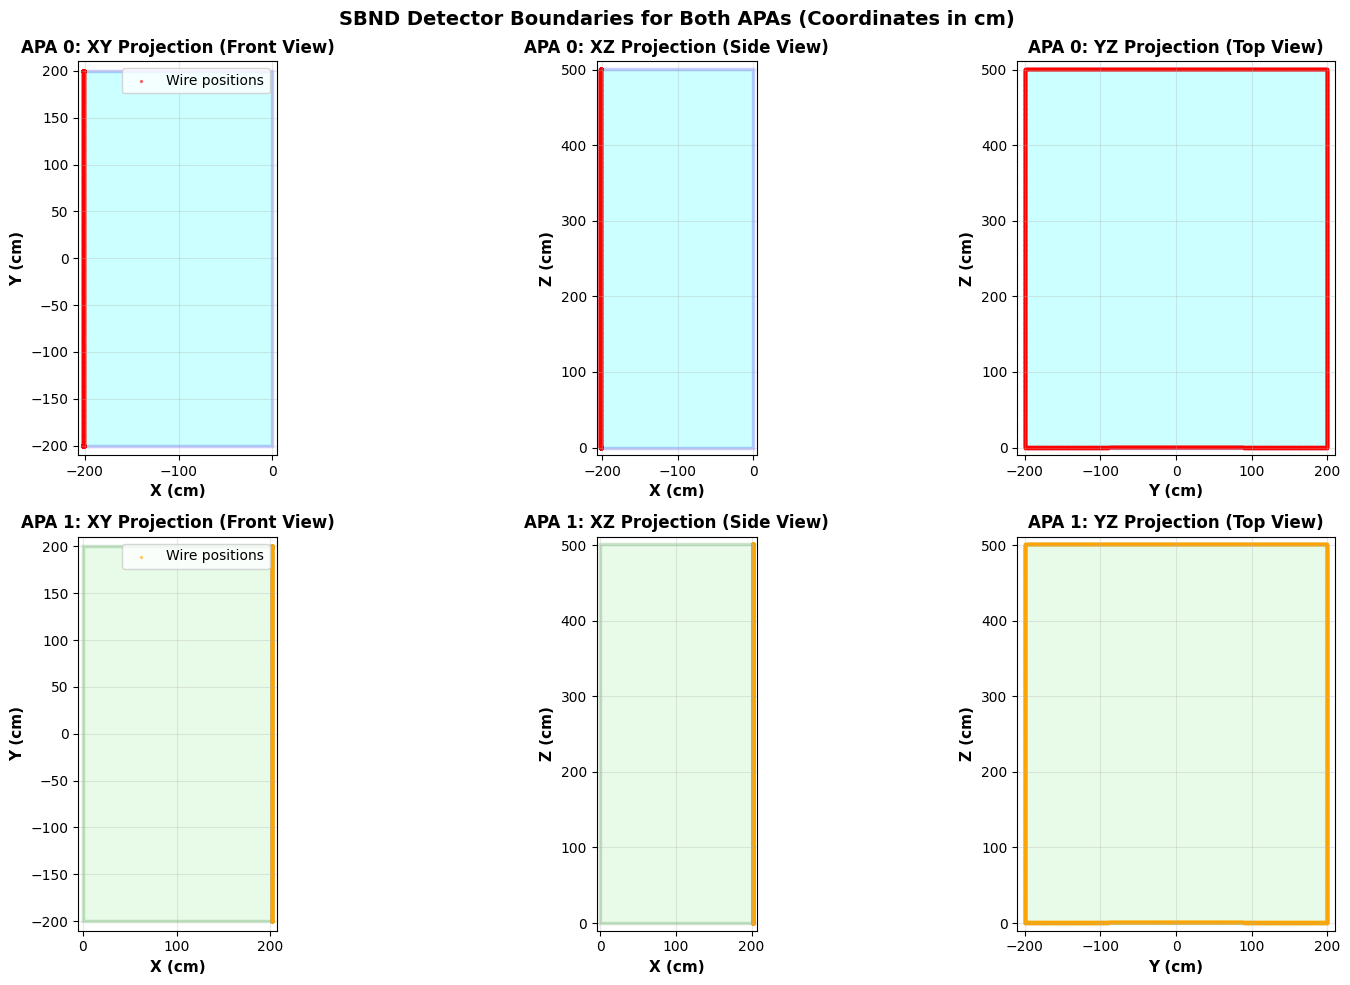

Detector boundary visualization saved!


In [8]:
# Create 2D projections for both APAs
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# APA 0 - XY Projection
ax = axes[0, 0]
rect = plt.Rectangle((apa0_bounds['x_min'], apa0_bounds['y_min']), 
                      apa0_bounds['x_max'] - apa0_bounds['x_min'],
                      apa0_bounds['y_max'] - apa0_bounds['y_min'],
                      linewidth=2.5, edgecolor='blue', facecolor='cyan', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa0_x, apa0_y, s=2, alpha=0.5, c='red', label='Wire positions')
ax.set_xlabel('X (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Y (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 0: XY Projection (Front View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa0_bounds['x_min'] - 5, apa0_bounds['x_max'] + 5)
ax.set_ylim(apa0_bounds['y_min'] - 10, apa0_bounds['y_max'] + 10)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')

# APA 0 - XZ Projection
ax = axes[0, 1]
rect = plt.Rectangle((apa0_bounds['x_min'], apa0_bounds['z_min']),
                      apa0_bounds['x_max'] - apa0_bounds['x_min'],
                      apa0_bounds['z_max'] - apa0_bounds['z_min'],
                      linewidth=2.5, edgecolor='blue', facecolor='cyan', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa0_x, apa0_z, s=2, alpha=0.5, c='red')
ax.set_xlabel('X (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Z (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 0: XZ Projection (Side View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa0_bounds['x_min'] - 5, apa0_bounds['x_max'] + 5)
ax.set_ylim(apa0_bounds['z_min'] - 10, apa0_bounds['z_max'] + 10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# APA 0 - YZ Projection
ax = axes[0, 2]
rect = plt.Rectangle((apa0_bounds['y_min'], apa0_bounds['z_min']),
                      apa0_bounds['y_max'] - apa0_bounds['y_min'],
                      apa0_bounds['z_max'] - apa0_bounds['z_min'],
                      linewidth=2.5, edgecolor='blue', facecolor='cyan', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa0_y, apa0_z, s=2, alpha=0.5, c='red')
ax.set_xlabel('Y (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Z (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 0: YZ Projection (Top View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa0_bounds['y_min'] - 10, apa0_bounds['y_max'] + 10)
ax.set_ylim(apa0_bounds['z_min'] - 10, apa0_bounds['z_max'] + 10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# APA 1 - XY Projection
ax = axes[1, 0]
rect = plt.Rectangle((apa1_bounds['x_min'], apa1_bounds['y_min']),
                      apa1_bounds['x_max'] - apa1_bounds['x_min'],
                      apa1_bounds['y_max'] - apa1_bounds['y_min'],
                      linewidth=2.5, edgecolor='green', facecolor='lightgreen', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa1_x, apa1_y, s=2, alpha=0.5, c='orange', label='Wire positions')
ax.set_xlabel('X (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Y (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 1: XY Projection (Front View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa1_bounds['x_min'] - 5, apa1_bounds['x_max'] + 5)
ax.set_ylim(apa1_bounds['y_min'] - 10, apa1_bounds['y_max'] + 10)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')

# APA 1 - XZ Projection
ax = axes[1, 1]
rect = plt.Rectangle((apa1_bounds['x_min'], apa1_bounds['z_min']),
                      apa1_bounds['x_max'] - apa1_bounds['x_min'],
                      apa1_bounds['z_max'] - apa1_bounds['z_min'],
                      linewidth=2.5, edgecolor='green', facecolor='lightgreen', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa1_x, apa1_z, s=2, alpha=0.5, c='orange')
ax.set_xlabel('X (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Z (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 1: XZ Projection (Side View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa1_bounds['x_min'] - 5, apa1_bounds['x_max'] + 5)
ax.set_ylim(apa1_bounds['z_min'] - 10, apa1_bounds['z_max'] + 10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# APA 1 - YZ Projection
ax = axes[1, 2]
rect = plt.Rectangle((apa1_bounds['y_min'], apa1_bounds['z_min']),
                      apa1_bounds['y_max'] - apa1_bounds['y_min'],
                      apa1_bounds['z_max'] - apa1_bounds['z_min'],
                      linewidth=2.5, edgecolor='green', facecolor='lightgreen', alpha=0.2)
ax.add_patch(rect)
ax.scatter(apa1_y, apa1_z, s=2, alpha=0.5, c='orange')
ax.set_xlabel('Y (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Z (cm)', fontsize=11, fontweight='bold')
ax.set_title('APA 1: YZ Projection (Top View)', fontsize=12, fontweight='bold')
ax.set_xlim(apa1_bounds['y_min'] - 10, apa1_bounds['y_max'] + 10)
ax.set_ylim(apa1_bounds['z_min'] - 10, apa1_bounds['z_max'] + 10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.suptitle('SBND Detector Boundaries for Both APAs (Coordinates in cm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/wirecell_boundaries_both_apas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Detector boundary visualization saved!')

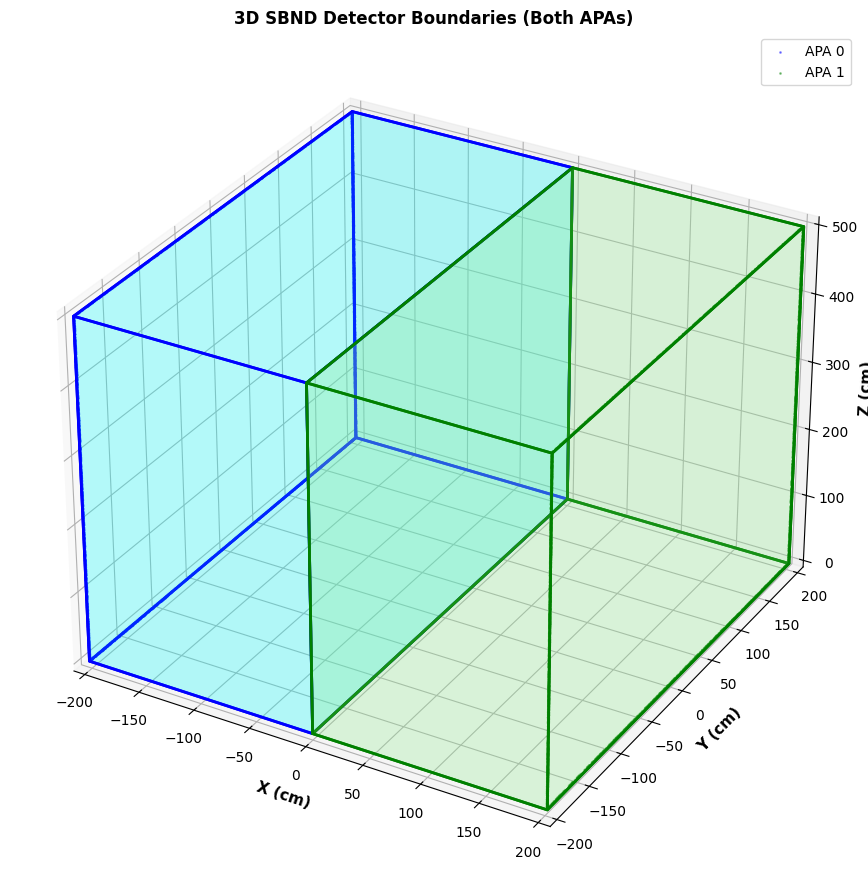

3D visualization saved!


In [9]:
# 3D visualization of both APAs
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def create_box_faces(x_min, x_max, y_min, y_max, z_min, z_max):
    vertices = [
        [x_min, y_min, z_min], [x_max, y_min, z_min], [x_max, y_max, z_min], [x_min, y_max, z_min],
        [x_min, y_min, z_max], [x_max, y_min, z_max], [x_max, y_max, z_max], [x_min, y_max, z_max]
    ]
    faces = [
        [vertices[0], vertices[1], vertices[5], vertices[4]],
        [vertices[2], vertices[3], vertices[7], vertices[6]],
        [vertices[0], vertices[3], vertices[7], vertices[4]],
        [vertices[1], vertices[2], vertices[6], vertices[5]],
        [vertices[0], vertices[1], vertices[2], vertices[3]],
        [vertices[4], vertices[5], vertices[6], vertices[7]]
    ]
    return faces

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Draw APA 0
apa0_faces = create_box_faces(apa0_bounds['x_min'], apa0_bounds['x_max'],
                              apa0_bounds['y_min'], apa0_bounds['y_max'],
                              apa0_bounds['z_min'], apa0_bounds['z_max'])
apa0_coll = Poly3DCollection(apa0_faces, alpha=0.15, linewidths=2, edgecolors='blue', facecolor='cyan')
ax.add_collection3d(apa0_coll)

# Draw APA 1
apa1_faces = create_box_faces(apa1_bounds['x_min'], apa1_bounds['x_max'],
                              apa1_bounds['y_min'], apa1_bounds['y_max'],
                              apa1_bounds['z_min'], apa1_bounds['z_max'])
apa1_coll = Poly3DCollection(apa1_faces, alpha=0.15, linewidths=2, edgecolors='green', facecolor='lightgreen')
ax.add_collection3d(apa1_coll)

# Scatter points
sample_size = 3000
idx0 = np.random.choice(len(apa0_x), min(sample_size, len(apa0_x)), replace=False)
idx1 = np.random.choice(len(apa1_x), min(sample_size, len(apa1_x)), replace=False)

ax.scatter(np.array(apa0_x)[idx0], np.array(apa0_y)[idx0], np.array(apa0_z)[idx0],
          c='blue', s=1, alpha=0.4, label='APA 0')
ax.scatter(np.array(apa1_x)[idx1], np.array(apa1_y)[idx1], np.array(apa1_z)[idx1],
          c='green', s=1, alpha=0.4, label='APA 1')

ax.set_xlabel('X (cm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Y (cm)', fontsize=11, fontweight='bold')
ax.set_zlabel('Z (cm)', fontsize=11, fontweight='bold')
ax.set_title('3D SBND Detector Boundaries (Both APAs)', fontsize=12, fontweight='bold')
ax.set_xlim(-210, 210)
ax.set_ylim(apa0_bounds['y_min'] - 10, apa0_bounds['y_max'] + 10)
ax.set_zlim(apa0_bounds['z_min'] - 10, apa0_bounds['z_max'] + 10)
ax.legend()

plt.tight_layout()
plt.savefig('/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/wirecell_boundary_3d_both_apas.png', dpi=150, bbox_inches='tight')
plt.show()
print('3D visualization saved!')

In [10]:
# Summary table
import pandas as pd

bounds_data = {
    'APA': ['APA 0', 'APA 0', 'APA 0', 'APA 1', 'APA 1', 'APA 1'],
    'Axis': ['X', 'Y', 'Z', 'X', 'Y', 'Z'],
    'Min (cm)': [f'{apa0_bounds["x_min"]:.2f}', f'{apa0_bounds["y_min"]:.2f}', f'{apa0_bounds["z_min"]:.2f}',
                  f'{apa1_bounds["x_min"]:.2f}', f'{apa1_bounds["y_min"]:.2f}', f'{apa1_bounds["z_min"]:.2f}'],
    'Max (cm)': [f'{apa0_bounds["x_max"]:.2f}', f'{apa0_bounds["y_max"]:.2f}', f'{apa0_bounds["z_max"]:.2f}',
                  f'{apa1_bounds["x_max"]:.2f}', f'{apa1_bounds["y_max"]:.2f}', f'{apa1_bounds["z_max"]:.2f}'],
    'Range (cm)': [f'{apa0_bounds["x_max"] - apa0_bounds["x_min"]:.2f}',
                    f'{apa0_bounds["y_max"] - apa0_bounds["y_min"]:.2f}',
                    f'{apa0_bounds["z_max"] - apa0_bounds["z_min"]:.2f}',
                    f'{apa1_bounds["x_max"] - apa1_bounds["x_min"]:.2f}',
                    f'{apa1_bounds["y_max"] - apa1_bounds["y_min"]:.2f}',
                    f'{apa1_bounds["z_max"] - apa1_bounds["z_min"]:.2f}']
}

df = pd.DataFrame(bounds_data)
print('\\n=== SBND Detector Geometry (By APA) ===')
print(df.to_string(index=False))

apa0_vol = (apa0_bounds['x_max'] - apa0_bounds['x_min']) * (apa0_bounds['y_max'] - apa0_bounds['y_min']) * (apa0_bounds['z_max'] - apa0_bounds['z_min']) / 1e6
apa1_vol = (apa1_bounds['x_max'] - apa1_bounds['x_min']) * (apa1_bounds['y_max'] - apa1_bounds['y_min']) * (apa1_bounds['z_max'] - apa1_bounds['z_min']) / 1e6

print(f'\\nAPA 0 Volume: {apa0_vol:.2e} cm³ ({len(apa0_points)} wires)')
print(f'APA 1 Volume: {apa1_vol:.2e} cm³ ({len(apa1_points)} wires)')
print(f'Total Volume: {apa0_vol + apa1_vol:.2e} cm³')

\n=== SBND Detector Geometry (By APA) ===
  APA Axis Min (cm) Max (cm) Range (cm)
APA 0    X  -202.05     0.00     202.05
APA 0    Y  -200.31   200.31     400.62
APA 0    Z    -0.15   501.15     501.30
APA 1    X     0.00   202.05     202.05
APA 1    Y  -200.31   200.31     400.62
APA 1    Z    -0.15   501.15     501.30
\nAPA 0 Volume: 4.06e+01 cm³ (11276 wires)
APA 1 Volume: 4.06e+01 cm³ (11276 wires)
Total Volume: 8.12e+01 cm³
